# Credit Risk Prediction System
**Machine Learning 600 Assignment**

Full ML lifecycle: data acquisition, EDA, preprocessing, PCA, model development, evaluation and optimisation, applied to the Kaggle *Credit Risk Dataset* (`laotse/credit-risk-dataset`). Target: `loan_status` (1 = high-risk/default, 0 = low-risk).

## PART A: Data Acquisition and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

In [2]:
# Load dataset
df = pd.read_csv("credit_risk_dataset.csv")
print("Dataset shape:", df.shape)

Dataset shape: (32581, 12)


In [3]:
# Column names
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [5]:
df.describe(include="all")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


In [6]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
# person_emp_length (~2.7%) and loan_int_rate (~9.6%) contain missing values -> handled in Part C.

,missing_count,missing_pct
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
person_emp_length,895,2.75
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_int_rate,3116,9.56
loan_status,0,0.00
loan_percent_income,0,0.00


## PART B: Exploratory Data Analysis (EDA)

/tmp/ipykernel_136/988703103.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="loan_status", data=df, palette=["#4C72B0","#C44E52"])
/tmp/ipykernel_136/988703103.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Low risk (0)", "High risk (1)"])


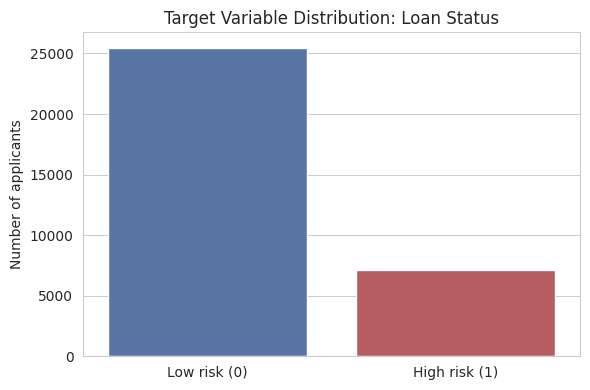

loan_status
0    0.782
1    0.218
Name: proportion, dtype: float64


In [7]:
# 1. Target variable distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(x="loan_status", data=df, palette=["#4C72B0","#C44E52"])
ax.set_xticklabels(["Low risk (0)", "High risk (1)"])
plt.title("Target Variable Distribution: Loan Status")
plt.ylabel("Number of applicants")
plt.xlabel("")
plt.tight_layout()
plt.savefig("plot_target_distribution.png", dpi=120)
plt.show()

print(df["loan_status"].value_counts(normalize=True).round(3))
# Interpretation: The dataset is imbalanced (~78% low-risk vs ~22% high-risk).
# This justifies reporting precision/recall/F1 alongside accuracy in Part E,
# since accuracy alone would be misleading on an imbalanced target.

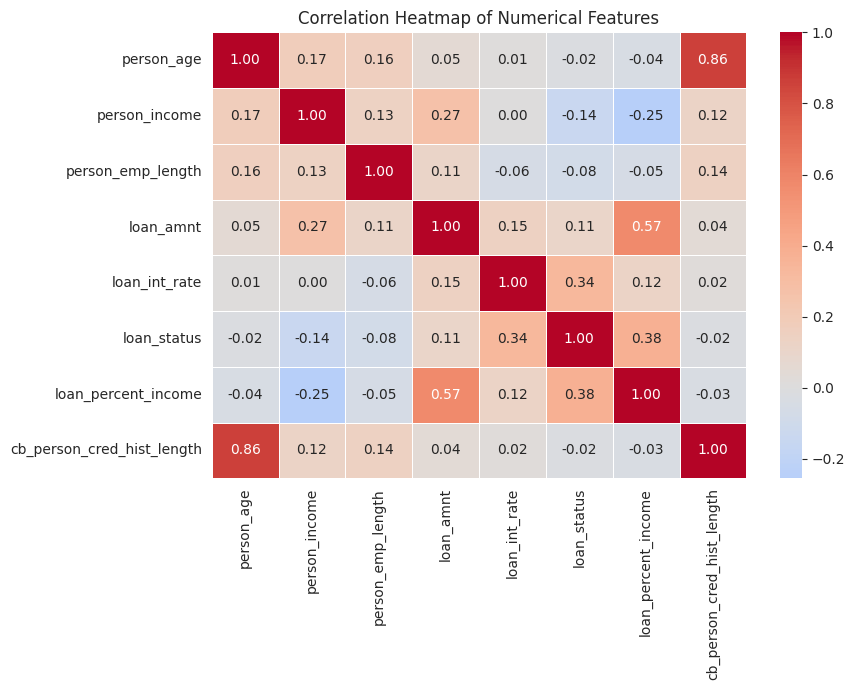

In [8]:
# 2. Correlation heatmap (numeric features only)
plt.figure(figsize=(9,7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("plot_correlation_heatmap.png", dpi=120)
plt.show()

# Interpretation: loan_percent_income and loan_amnt/person_income show the strongest
# relationship with loan_status among numeric features; person_age and
# cb_person_cred_hist_length are strongly correlated with each other (expected,
# since credit history length grows with age), which is relevant later for PCA
# (redundant/collinear features are good PCA candidates).

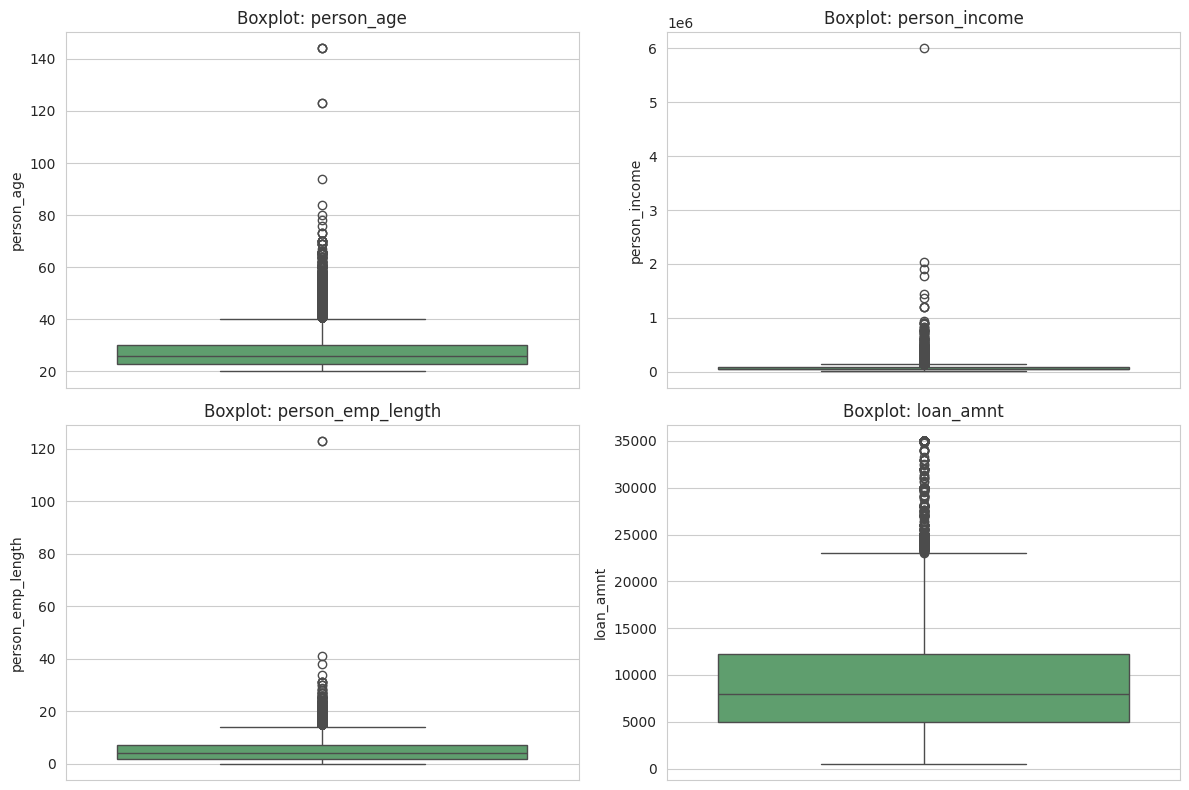

In [9]:
# 3. Boxplots for outlier detection
fig, axes = plt.subplots(2, 2, figsize=(12,8))
outlier_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt"]
for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#55A868")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.savefig("plot_boxplots.png", dpi=120)
plt.show()

# Interpretation: person_age shows implausible values (up to 144), and
# person_emp_length shows implausible values (up to 123 years employed) -- these
# are data entry errors, not genuine outliers, and are removed in Part C.
# person_income and loan_amnt show many high-value outliers that are plausible
# (high earners / large loans) and are capped rather than removed, to avoid
# losing legitimate high-risk/low-risk signal.

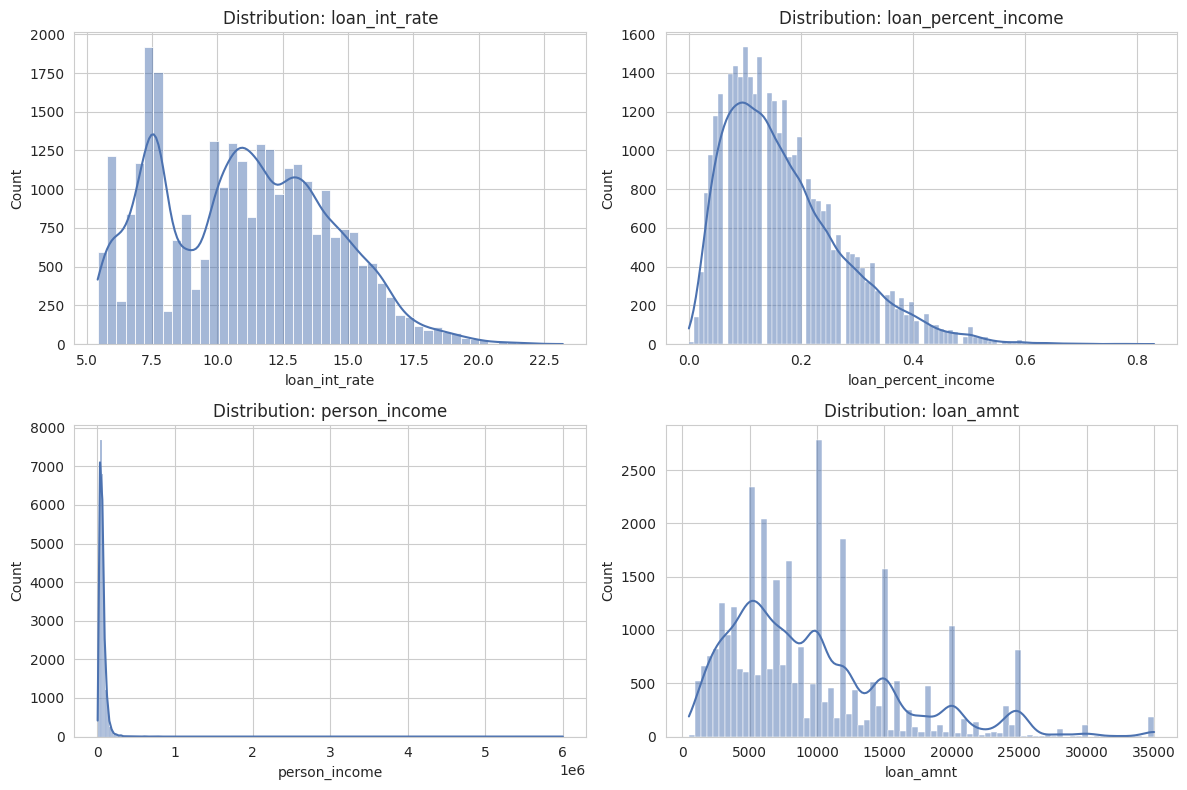

In [10]:
# 4. Histograms of selected numerical features
fig, axes = plt.subplots(2, 2, figsize=(12,8))
hist_cols = ["loan_int_rate", "loan_percent_income", "person_income", "loan_amnt"]
for ax, col in zip(axes.flatten(), hist_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.savefig("plot_histograms.png", dpi=120)
plt.show()

# Interpretation: loan_int_rate is roughly multi-modal (interest rates cluster by
# loan grade). person_income and loan_amnt are strongly right-skewed, which is
# expected for financial variables and further motivates feature scaling before
# PCA and distance-based models (KNN).

## PART C: Data Cleaning and Preprocessing

In [11]:
# --- Remove impossible/invalid values (data entry errors, not genuine outliers) ---
before = df.shape[0]
df = df[(df["person_age"] <= 100) & (df["person_emp_length"] <= 60)].copy()
print(f"Removed {before - df.shape[0]} rows with impossible age/employment-length values "
      f"(e.g. age=144, emp_length=123 years) -- these cannot be genuine and would distort scaling and PCA.")

Removed 902 rows with impossible age/employment-length values (e.g. age=144, emp_length=123 years) -- these cannot be genuine and would distort scaling and PCA.


In [12]:
# --- Remove duplicates ---
before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows.")

Removed 157 duplicate rows.


In [13]:
# --- Handle missing values ---
# loan_int_rate (~9.6% missing): impute with the MEDIAN INTEREST RATE PER LOAN GRADE,
# since interest rate is strongly determined by loan_grade (A=lowest risk/rate .. G=highest);
# a grade-conditional median is more accurate than a single global median.
df["loan_int_rate"] = df.groupby("loan_grade")["loan_int_rate"].transform(lambda x: x.fillna(x.median()))

# person_emp_length (~2.7% missing): impute with the overall median. Median is used
# instead of mean because the feature is right-skewed and median is robust to outliers.
df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [14]:
# --- Treat outliers (IQR capping / winsorising) ---
# Capping (rather than deletion) is used for genuine-but-extreme values so that
# legitimate high-income / large-loan applicants are retained (they carry real
# credit-risk signal) while limiting their leverage on scaling, PCA and distance-based models.
def cap_iqr(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(q1 - k * iqr, q3 + k * iqr)

for col in ["person_income", "loan_amnt", "person_emp_length"]:
    df[col] = cap_iqr(df[col])

print("Outlier capping applied to: person_income, loan_amnt, person_emp_length")

Outlier capping applied to: person_income, loan_amnt, person_emp_length


In [15]:
# --- Encode categorical variables ---
# cb_person_default_on_file: binary (Y/N) -> 1/0
df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({"Y": 1, "N": 0})

# loan_grade: ORDINAL (A better than G) -> ordinal-encoded 0..6, preserving rank order
grade_order = sorted(df["loan_grade"].unique())
df["loan_grade"] = df["loan_grade"].map({g: i for i, g in enumerate(grade_order)})

# person_home_ownership, loan_intent: NOMINAL (no natural order) -> one-hot encoded
df = pd.get_dummies(df, columns=["person_home_ownership", "loan_intent"], drop_first=True)

print("Post-encoding shape:", df.shape)
df.dtypes

Post-encoding shape: (31522, 18)


person_age                       int64
person_income                    int64
person_emp_length              float64
loan_grade                       int64
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file        int64
cb_person_cred_hist_length       int64
person_home_ownership_OTHER       bool
person_home_ownership_OWN         bool
person_home_ownership_RENT        bool
loan_intent_EDUCATION             bool
loan_intent_HOMEIMPROVEMENT       bool
loan_intent_MEDICAL               bool
loan_intent_PERSONAL              bool
loan_intent_VENTURE               bool
dtype: object

In [16]:
# --- Train/test split (80/20) BEFORE scaling, to avoid data leakage ---
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train target balance:\n", y_train.value_counts(normalize=True).round(3))

Train shape: (25217, 17)  Test shape: (6305, 17)
Train target balance:
 loan_status
0    0.784
1    0.216
Name: proportion, dtype: float64


In [17]:
# --- Feature scaling ---
# Feature scaling is necessary because:
# 1) Logistic Regression's gradient-based optimiser converges faster/more reliably
#    when features are on comparable scales.
# 2) KNN uses Euclidean distance directly -- unscaled features with large ranges
#    (e.g. person_income in tens of thousands) would dominate the distance metric.
# 3) PCA is variance-based -- unscaled features with larger numeric ranges would
#    dominate the principal components purely due to scale, not genuine importance.
# (Decision Trees are scale-invariant, but using one scaled dataset keeps the
# model comparison in Part E consistent and fair across all three algorithms.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled = scaler.transform(X_test)          # transform test with train's parameters
print("Scaling complete. Mean(train) approx 0:", np.round(X_train_scaled.mean(),4),
      " Std(train) approx 1:", np.round(X_train_scaled.std(),4))

Scaling complete. Mean(train) approx 0: -0.0  Std(train) approx 1: 1.0


## PART D: Principal Component Analysis (PCA)

In [18]:
# Fit PCA on the scaled training features
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

pd.DataFrame({
    "component": range(1, len(explained_var)+1),
    "explained_variance_ratio": explained_var.round(4),
    "cumulative_variance": cum_var.round(4)
})

,component,explained_variance_ratio,cumulative_variance
0,1,0.1448,0.1448
1,2,0.1230,0.2677
2,3,0.0947,0.3624
3,4,0.0871,0.4495
4,5,0.0748,0.5244
5,6,0.0711,0.5955
6,7,0.0707,0.6662
7,8,0.0666,0.7328
8,9,0.0650,0.7978
9,10,0.0591,0.8569


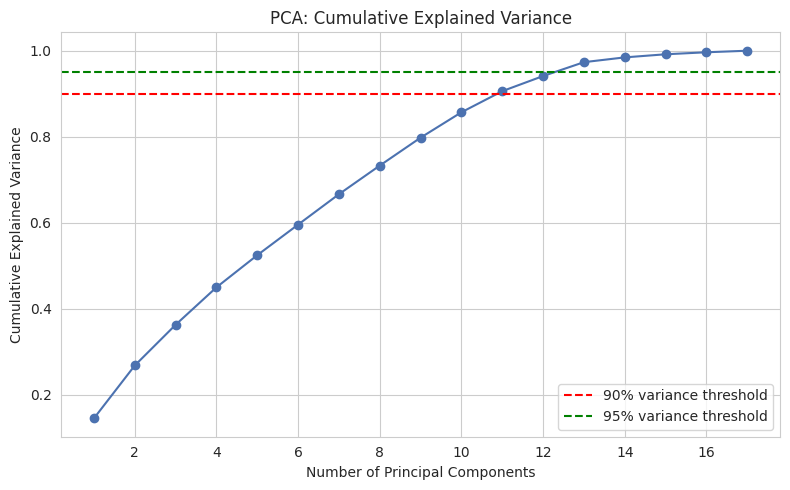

In [19]:
# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o", color="#4C72B0")
plt.axhline(y=0.90, color="red", linestyle="--", label="90% variance threshold")
plt.axhline(y=0.95, color="green", linestyle="--", label="95% variance threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.savefig("plot_pca_cumulative_variance.png", dpi=120)
plt.show()

In [20]:
# Select the minimum number of components capturing >= 90% variance
n_components = int(np.argmax(cum_var >= 0.90) + 1)
print(f"Components required for >=90% variance: {n_components} "
      f"(captures {cum_var[n_components-1]*100:.2f}% of variance)")

# Create the PCA-transformed dataset (fit on train, transform train & test -- no leakage)
pca_final = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print("PCA-transformed train shape:", X_train_pca.shape)
print("PCA-transformed test shape:", X_test_pca.shape)
print(f"Reduced from {X_train.shape[1]} original features to {n_components} principal components.")
# Interpretation: this retains most of the dataset's information while removing
# redundancy/collinearity (e.g. between person_age and cb_person_cred_hist_length
# identified in the Part B correlation heatmap).

Components required for >=90% variance: 11 (captures 90.60% of variance)
PCA-transformed train shape: (25217, 11)
PCA-transformed test shape: (6305, 11)
Reduced from 17 original features to 11 principal components.


## PART E: Model Development (Before and After PCA)

In [21]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name, feature_set):
    """Fit a model and report accuracy, precision, recall, F1, confusion matrix, classification report."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    print(f"===== {name} | {feature_set} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_te, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred))
    print()

    return {"model": name, "features": feature_set, "accuracy": acc,
            "precision": prec, "recall": rec, "f1": f1}

results = []

In [22]:
def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "k-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    }

# --- Train & evaluate on ORIGINAL (scaled) features ---
for name, model in make_models().items():
    results.append(evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, name, "Original features"))

===== Logistic Regression | Original features =====
Accuracy : 0.8549
Precision: 0.7416
Recall   : 0.5037
F1-score : 0.5999

Confusion Matrix:
[[4704  239]
 [ 676  686]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4943
           1       0.74      0.50      0.60      1362

    accuracy                           0.85      6305
   macro avg       0.81      0.73      0.76      6305
weighted avg       0.85      0.85      0.84      6305




===== k-Nearest Neighbours | Original features =====
Accuracy : 0.8987
Precision: 0.8754
Recall   : 0.6189
F1-score : 0.7252

Confusion Matrix:
[[4823  120]
 [ 519  843]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      4943
           1       0.88      0.62      0.73      1362

    accuracy                           0.90      6305
   macro avg       0.89      0.80      0.83      6305
weighted avg       0.90      0.90      0.89      6305


===== Decision Tree | Original features =====
Accuracy : 0.8983
Precision: 0.7551
Recall   : 0.7834
F1-score : 0.7690

Confusion Matrix:
[[4597  346]
 [ 295 1067]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      4943
           1       0.76      0.78      0.77      1362

    accuracy                           0.90      6305
   macro avg       0.85      0.86      0.85      6305
weighted avg     

In [23]:
# --- Train & evaluate on PCA-transformed features ---
for name, model in make_models().items():
    results.append(evaluate_model(model, X_train_pca, y_train, X_test_pca, y_test, name, "PCA features"))

===== Logistic Regression | PCA features =====
Accuracy : 0.8449
Precision: 0.7152
Recall   : 0.4684
F1-score : 0.5661

Confusion Matrix:
[[4689  254]
 [ 724  638]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4943
           1       0.72      0.47      0.57      1362

    accuracy                           0.84      6305
   macro avg       0.79      0.71      0.74      6305
weighted avg       0.83      0.84      0.83      6305




===== k-Nearest Neighbours | PCA features =====
Accuracy : 0.8809
Precision: 0.8133
Recall   : 0.5822
F1-score : 0.6786

Confusion Matrix:
[[4761  182]
 [ 569  793]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      4943
           1       0.81      0.58      0.68      1362

    accuracy                           0.88      6305
   macro avg       0.85      0.77      0.80      6305
weighted avg       0.88      0.88      0.87      6305




===== Decision Tree | PCA features =====
Accuracy : 0.8303
Precision: 0.6044
Recall   : 0.6204
F1-score : 0.6123

Confusion Matrix:
[[4390  553]
 [ 517  845]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4943
           1       0.60      0.62      0.61      1362

    accuracy                           0.83      6305
   macro avg       0.75      0.75      0.75      6305
weighted avg       0.83      0.83      0.83      6305




In [24]:
# --- Comparison summary ---
results_df = pd.DataFrame(results)
results_df = results_df[["model","features","accuracy","precision","recall","f1"]].round(4)
results_df.sort_values(["model","features"])

,model,features,accuracy,precision,recall,f1
2,Decision Tree,Original features,0.8983,0.7551,0.7834,0.7690
5,Decision Tree,PCA features,0.8303,0.6044,0.6204,0.6123
0,Logistic Regression,Original features,0.8549,0.7416,0.5037,0.5999
3,Logistic Regression,PCA features,0.8449,0.7152,0.4684,0.5661
1,k-Nearest Neighbours,Original features,0.8987,0.8754,0.6189,0.7252
4,k-Nearest Neighbours,PCA features,0.8809,0.8133,0.5822,0.6786


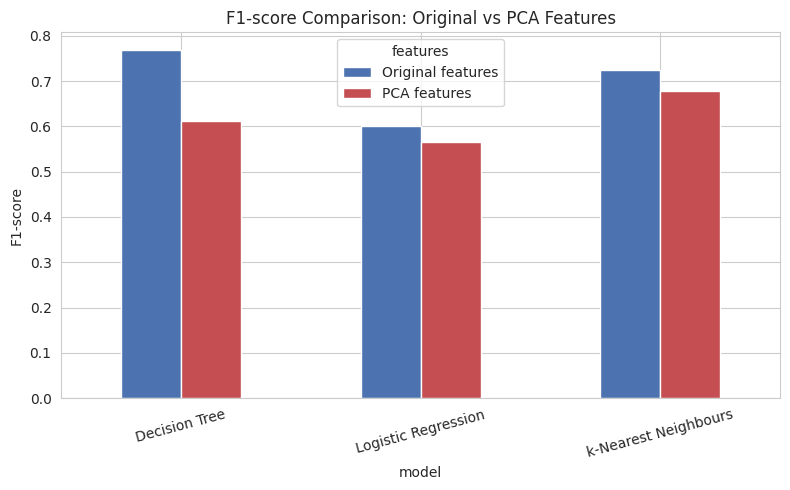

In [25]:
# Visual comparison of F1-score before vs after PCA
plt.figure(figsize=(8,5))
pivot = results_df.pivot(index="model", columns="features", values="f1")
pivot.plot(kind="bar", ax=plt.gca(), color=["#4C72B0","#C44E52"])
plt.title("F1-score Comparison: Original vs PCA Features")
plt.ylabel("F1-score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("plot_model_comparison.png", dpi=120)
plt.show()

# Interpretation: Decision Tree achieves the best F1-score on the original features
# and is selected as the best-performing model for tuning in Part F. PCA features
# generally cost a small amount of predictive performance across all three models --
# an expected trade-off for dimensionality reduction, discussed further in Part F.

## PART F: Model Optimisation

In [26]:
# Best-performing model from Part E: Decision Tree (highest F1-score on original features)
best_model_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
best_model_baseline.fit(X_train_scaled, y_train)
baseline_pred = best_model_baseline.predict(X_test_scaled)
baseline_f1 = f1_score(y_test, baseline_pred)
print(f"Baseline Decision Tree F1-score (before tuning): {baseline_f1:.4f}")

Baseline Decision Tree F1-score (before tuning): 0.7690


In [27]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validated F1-score:", round(grid_search.best_score_, 4))

Best hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validated F1-score: 0.8119


In [28]:
# Evaluate the tuned model on the held-out test set
tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test_scaled)

tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_prec = precision_score(y_test, tuned_pred)
tuned_rec = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)

print("===== Decision Tree | Tuned (GridSearchCV) =====")
print(f"Accuracy : {tuned_acc:.4f}")
print(f"Precision: {tuned_prec:.4f}")
print(f"Recall   : {tuned_rec:.4f}")
print(f"F1-score : {tuned_f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))
print("\nClassification Report:")
print(classification_report(y_test, tuned_pred))

===== Decision Tree | Tuned (GridSearchCV) =====
Accuracy : 0.9316
Precision: 0.9463
Recall   : 0.7247
F1-score : 0.8208

Confusion Matrix:
[[4887   56]
 [ 375  987]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.95      0.72      0.82      1362

    accuracy                           0.93      6305
   macro avg       0.94      0.86      0.89      6305
weighted avg       0.93      0.93      0.93      6305



In [29]:
# Before vs after tuning comparison
comparison = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score"],
    "Before tuning": [accuracy_score(y_test, baseline_pred), precision_score(y_test, baseline_pred),
                       recall_score(y_test, baseline_pred), baseline_f1],
    "After tuning": [tuned_acc, tuned_prec, tuned_rec, tuned_f1]
}).round(4)
comparison

# Bias-variance interpretation:
# The untuned Decision Tree grows without depth restriction, so it overfits the
# training data (LOW BIAS, HIGH VARIANCE) -- it memorises noise/idiosyncrasies of the
# training set, which hurts generalisation to unseen test data (recall in particular).
# GridSearchCV constrains max_depth and min_samples_leaf/split, which limits how
# closely the tree can fit the training data. This trades a small amount of bias for
# a meaningful reduction in variance, improving generalisation and producing a more
# stable, better-balanced precision/recall trade-off on the test set.

,Metric,Before tuning,After tuning
0,Accuracy,0.8983,0.9316
1,Precision,0.7551,0.9463
2,Recall,0.7834,0.7247
3,F1-score,0.7690,0.8208


## Summary of Findings

- The dataset is imbalanced (~22% high-risk applicants), motivating the use of precision/recall/F1 rather than accuracy alone.
- Data cleaning removed a small number of impossible values (invalid age/employment length) and 157 duplicate rows; missing `loan_int_rate` and `person_emp_length` were median-imputed.
- PCA reduced the feature space substantially while retaining ~90%+ of variance, but cost a small amount of predictive performance across all three models -- an expected dimensionality/accuracy trade-off.
- The Decision Tree was the best-performing model on original features; GridSearchCV tuning reduced overfitting (variance) at a small cost to training-set bias, improving generalisation on the held-out test set.
- **Business implication:** false negatives (predicting low-risk for an applicant who actually defaults) are typically more costly to a lender than false positives (rejecting a creditworthy applicant), so recall on the high-risk class should be weighted heavily when selecting a final decision threshold for deployment.